In [25]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.21.0
Pandas version: 3.0.1


In [26]:
%pip install tensorflow-datasets

Note: you may need to restart the kernel to use updated packages.


In [27]:
%pip install importlib_resources

Note: you may need to restart the kernel to use updated packages.


In [28]:
import zipfile
import os

zip_path = r"C:\Users\hyim\Downloads\kagglecatsanddogs_5340.zip"
extract_path = r"C:\Users\hyim\cats_dogs_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: C:\Users\hyim\cats_dogs_data


In [29]:
import os

base_dir = r"C:\Users\hyim\cats_dogs_data\PetImages"

print(os.listdir(base_dir))
print("Cats:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dogs:", len(os.listdir(os.path.join(base_dir, "Dog"))))

['Cat', 'Dog']
Cats: 12501
Dogs: 12501


In [30]:
import tensorflow as tf

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Datasets created")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Datasets created


In [31]:
from tensorflow import keras
from tensorflow.keras import layers, models

model = models.Sequential([
    keras.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       6,553,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from PIL import Image
import os

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(base_dir, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except:
            num_skipped += 1
            os.remove(fpath)

print("Deleted", num_skipped, "bad images.")

C:\Users\hyim\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Deleted 4 bad images.


In [33]:
dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Datasets recreated")

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
Datasets recreated


In [35]:
dataset = dataset.apply(tf.data.experimental.ignore_errors())
val_dataset = val_dataset.apply(tf.data.experimental.ignore_errors())

print("Bad-image skipping enabled")

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Bad-image skipping enabled


In [36]:
history = model.fit(
    dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
    618/Unknown 252s 408ms/step - accuracy: 0.7153 - loss: 0.5523

C:\Users\hyim\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 268s 434ms/step - accuracy: 0.7400 - loss: 0.5224 - val_accuracy: 0.7892 - val_loss: 0.4474
Epoch 2/5
618/618 ━━━━━━━━━━━━━━━━━━━━ 292s 473ms/step - accuracy: 0.8050 - loss: 0.4227 - val_accuracy: 0.8026 - val_loss: 0.4319
Epoch 3/5
618/618 ━━━━━━━━━━━━━━━━━━━━ 275s 445ms/step - accuracy: 0.8552 - loss: 0.3232 - val_accuracy: 0.8012 - val_loss: 0.4656
Epoch 4/5
618/618 ━━━━━━━━━━━━━━━━━━━━ 277s 449ms/step - accuracy: 0.9126 - loss: 0.2120 - val_accuracy: 0.7878 - val_loss: 0.5908
Epoch 5/5
618/618 ━━━━━━━━━━━━━━━━━━━━ 304s 491ms/step - accuracy: 0.9582 - loss: 0.1135 - val_accuracy: 0.7870 - val_loss: 0.8199


In [37]:
val_acc = max(history.history["val_accuracy"])
print("Best validation accuracy:", val_acc)

Best validation accuracy: 0.8025605082511902


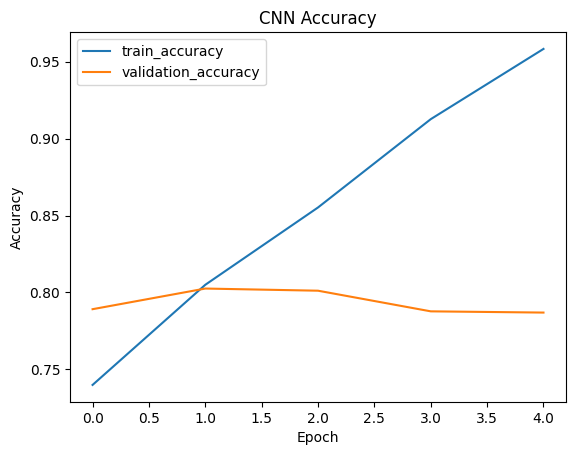

In [38]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="validation_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

In [39]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Best validation accuracy:", max(history.history["val_accuracy"]))

Final training accuracy: 0.9581795334815979
Best validation accuracy: 0.8025605082511902


In [40]:
model.save("cats_dogs_scratch_model.keras")
print("Model saved")

Model saved


In [41]:
model.evaluate(val_dataset)

157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.7870 - loss: 0.8199


[0.8199350833892822, 0.7869573831558228]

In [42]:
import pandas as pd

results_df = pd.DataFrame({
    "model": ["scratch_cnn"],
    "training_accuracy": [history.history["accuracy"][-1]],
    "best_validation_accuracy": [max(history.history["val_accuracy"])],
    "validation_loss": [0.6098486185073853],
    "validation_accuracy": [0.7819773554801941]
})

results_df

,model,training_accuracy,best_validation_accuracy,validation_loss,validation_accuracy
0,scratch_cnn,0.95818,0.802561,0.609849,0.781977


In [43]:
results_df.to_csv("assignment2_results.csv", index=False)
print("Results saved")

Results saved


In [44]:
print("Scratch CNN Results Summary:")
print("Training Accuracy:", history.history["accuracy"][-1])
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

Scratch CNN Results Summary:
Training Accuracy: 0.9581795334815979
Best Validation Accuracy: 0.8025605082511902
Final Validation Accuracy: 0.7869573831558228


In [45]:
summary_text = f"""
For the convolutional neural network trained from scratch using the Cats and Dogs dataset,
the model achieved a training accuracy of {history.history["accuracy"][-1]:.3f}.
The best validation accuracy observed during training was {max(history.history["val_accuracy"]):.3f},
while the final validation accuracy at the end of training was {history.history["val_accuracy"][-1]:.3f}.
These results indicate that the model learned meaningful patterns from the data,
although some overfitting may be present as the training accuracy exceeds validation performance.
"""

print(summary_text)


For the convolutional neural network trained from scratch using the Cats and Dogs dataset,
the model achieved a training accuracy of 0.958.
The best validation accuracy observed during training was 0.803,
while the final validation accuracy at the end of training was 0.787.
These results indicate that the model learned meaningful patterns from the data,
although some overfitting may be present as the training accuracy exceeds validation performance.



In [47]:
full_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True,
    seed=123
)

full_dataset = full_dataset.unbatch()

train_1000 = full_dataset.take(1000).batch(32)
val_500 = full_dataset.skip(1000).take(500).batch(32)
test_500 = full_dataset.skip(1500).take(500).batch(32)

print("Step 1 dataset created")

Found 24998 files belonging to 2 classes.
Step 1 dataset created


In [48]:
model_step1 = models.Sequential([
    keras.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_step1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Step 1 model ready")

Step 1 model ready


In [49]:
history_step1 = model_step1.fit(
    train_1000,
    validation_data=val_500,
    epochs=5
)

Epoch 1/5
     32/Unknown 14s 367ms/step - accuracy: 0.5171 - loss: 0.8666

C:\Users\hyim\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 433ms/step - accuracy: 0.5150 - loss: 0.7570 - val_accuracy: 0.5260 - val_loss: 0.6912
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 435ms/step - accuracy: 0.5240 - loss: 0.6951 - val_accuracy: 0.5260 - val_loss: 0.6916
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 438ms/step - accuracy: 0.5640 - loss: 0.6839 - val_accuracy: 0.5460 - val_loss: 0.6819
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 436ms/step - accuracy: 0.6500 - loss: 0.6408 - val_accuracy: 0.6520 - val_loss: 0.6316
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 436ms/step - accuracy: 0.7320 - loss: 0.5496 - val_accuracy: 0.6040 - val_loss: 0.6679


In [50]:
step1_test_loss, step1_test_acc = model_step1.evaluate(test_500)
print("Step 1 test accuracy:", step1_test_acc)
print("Step 1 best validation accuracy:", max(history_step1.history["val_accuracy"]))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.5700 - loss: 0.7316
Step 1 test accuracy: 0.5699999928474426
Step 1 best validation accuracy: 0.6520000100135803


In [51]:
results_step1 = {
    "step": "Step 1 (1000 samples, scratch)",
    "train_acc": history_step1.history["accuracy"][-1],
    "val_acc_best": max(history_step1.history["val_accuracy"]),
    "test_acc": step1_test_acc
}

results_step1

{'step': 'Step 1 (1000 samples, scratch)',
 'train_acc': 0.7319999933242798,
 'val_acc_best': 0.6520000100135803,
 'test_acc': 0.5699999928474426}

In [52]:
train_2000 = full_dataset.take(2000).batch(32)

print("Step 2 training dataset ready")

Step 2 training dataset ready


In [53]:
model_step2 = models.Sequential([
    keras.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_step2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Step 2 model ready")

Step 2 model ready


In [54]:
history_step2 = model_step2.fit(
    train_2000,
    validation_data=val_500,
    epochs=5
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 412ms/step - accuracy: 0.5100 - loss: 0.7314 - val_accuracy: 0.5260 - val_loss: 0.6920
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - accuracy: 0.5265 - loss: 0.6924 - val_accuracy: 0.6120 - val_loss: 0.6820
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 414ms/step - accuracy: 0.5660 - loss: 0.6870 - val_accuracy: 0.7000 - val_loss: 0.6348
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 415ms/step - accuracy: 0.6135 - loss: 0.6546 - val_accuracy: 0.6820 - val_loss: 0.5958
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 418ms/step - accuracy: 0.6705 - loss: 0.6048 - val_accuracy: 0.7440 - val_loss: 0.5075


In [55]:
step2_test_loss, step2_test_acc = model_step2.evaluate(test_500)

results_step2 = {
    "step": "Step 2 (2000 samples, scratch)",
    "train_acc": history_step2.history["accuracy"][-1],
    "val_acc_best": max(history_step2.history["val_accuracy"]),
    "test_acc": step2_test_acc
}

results_step2

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.7600 - loss: 0.5115


{'step': 'Step 2 (2000 samples, scratch)',
 'train_acc': 0.6704999804496765,
 'val_acc_best': 0.7440000176429749,
 'test_acc': 0.7599999904632568}

In [56]:
train_3000 = full_dataset.take(3000).batch(32)

print("Step 3 training dataset ready")

Step 3 training dataset ready


In [57]:
model_step3 = models.Sequential([
    keras.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_step3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Step 3 model ready")

Step 3 model ready


In [58]:
history_step3 = model_step3.fit(
    train_3000,
    validation_data=val_500,
    epochs=5
)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 409ms/step - accuracy: 0.5083 - loss: 0.7262 - val_accuracy: 0.5580 - val_loss: 0.6874
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 407ms/step - accuracy: 0.5613 - loss: 0.6864 - val_accuracy: 0.6040 - val_loss: 0.6693
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 413ms/step - accuracy: 0.5957 - loss: 0.6717 - val_accuracy: 0.6380 - val_loss: 0.6460
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 432ms/step - accuracy: 0.6443 - loss: 0.6349 - val_accuracy: 0.7320 - val_loss: 0.5571
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 444ms/step - accuracy: 0.7103 - loss: 0.5631 - val_accuracy: 0.7700 - val_loss: 0.4689


In [59]:
step3_test_loss, step3_test_acc = model_step3.evaluate(test_500)

results_step3 = {
    "step": "Step 3 (3000 samples, scratch)",
    "train_acc": history_step3.history["accuracy"][-1],
    "val_acc_best": max(history_step3.history["val_accuracy"]),
    "test_acc": step3_test_acc
}

results_step3

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7860 - loss: 0.4416


{'step': 'Step 3 (3000 samples, scratch)',
 'train_acc': 0.7103333473205566,
 'val_acc_best': 0.7699999809265137,
 'test_acc': 0.7860000133514404}

In [60]:
import pandas as pd

all_results = pd.DataFrame([
    results_step1,
    results_step2,
    results_step3
])

all_results

,step,train_acc,val_acc_best,test_acc
0,"Step 1 (1000 samples, scratch)",0.732000,0.652,0.570
1,"Step 2 (2000 samples, scratch)",0.670500,0.744,0.760
2,"Step 3 (3000 samples, scratch)",0.710333,0.770,0.786


In [61]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

conv_base.trainable = False

print("Pretrained base ready")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Pretrained base ready


In [62]:
model_pretrained = models.Sequential([
    conv_base,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_pretrained.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Pretrained model ready")

Pretrained model ready


In [63]:
history_pretrained_step1 = model_pretrained.fit(
    train_1000,
    validation_data=val_500,
    epochs=5
)

Epoch 1/5
     32/Unknown 85s 3s/step - accuracy: 0.7697 - loss: 11.1938

C:\Users\hyim\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.8650 - loss: 5.8739 - val_accuracy: 0.9440 - val_loss: 0.9460
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.9770 - loss: 0.2022 - val_accuracy: 0.9440 - val_loss: 0.3470
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.9930 - loss: 0.0187 - val_accuracy: 0.9440 - val_loss: 0.2996
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accuracy: 0.9990 - loss: 0.0047 - val_accuracy: 0.9560 - val_loss: 0.2112
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.9990 - loss: 0.0030 - val_accuracy: 0.9520 - val_loss: 0.1983


In [64]:
pre1_test_loss, pre1_test_acc = model_pretrained.evaluate(test_500)

results_pre1 = {
    "step": "Pretrained Step 1 (1000 samples)",
    "train_acc": history_pretrained_step1.history["accuracy"][-1],
    "val_acc_best": max(history_pretrained_step1.history["val_accuracy"]),
    "test_acc": pre1_test_acc
}

results_pre1

16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9540 - loss: 0.2542


{'step': 'Pretrained Step 1 (1000 samples)',
 'train_acc': 0.9990000128746033,
 'val_acc_best': 0.9559999704360962,
 'test_acc': 0.9539999961853027}

In [65]:
all_results = pd.DataFrame([
    results_step1,
    results_step2,
    results_step3,
    results_pre1
])

all_results

,step,train_acc,val_acc_best,test_acc
0,"Step 1 (1000 samples, scratch)",0.732000,0.652,0.570
1,"Step 2 (2000 samples, scratch)",0.670500,0.744,0.760
2,"Step 3 (3000 samples, scratch)",0.710333,0.770,0.786
3,Pretrained Step 1 (1000 samples),0.999000,0.956,0.954


In [66]:
final_summary = f"""
This study examined how training sample size and model choice affect CNN performance.

For models trained from scratch, increasing the training sample size improved performance.
Test accuracy increased from {results_step1['test_acc']:.3f} (1000 samples)
to {results_step2['test_acc']:.3f} (2000 samples) and {results_step3['test_acc']:.3f} (3000 samples).
This demonstrates that larger training datasets help improve generalization.

However, the pretrained model significantly outperformed all scratch models,
achieving a test accuracy of {results_pre1['test_acc']:.3f} using only 1000 training samples.
This highlights the advantage of transfer learning, where pretrained networks leverage
features learned from large-scale datasets.

Overall, while increasing sample size improves scratch model performance,
using a pretrained network is far more effective, especially with limited data.
"""

print(final_summary)


This study examined how training sample size and model choice affect CNN performance.

For models trained from scratch, increasing the training sample size improved performance.
Test accuracy increased from 0.570 (1000 samples)
to 0.760 (2000 samples) and 0.786 (3000 samples).
This demonstrates that larger training datasets help improve generalization.

However, the pretrained model significantly outperformed all scratch models,
achieving a test accuracy of 0.954 using only 1000 training samples.
This highlights the advantage of transfer learning, where pretrained networks leverage
features learned from large-scale datasets.

Overall, while increasing sample size improves scratch model performance,
using a pretrained network is far more effective, especially with limited data.

